In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yaml

cfg = yaml.safe_load(open('configs/settings.yaml'))


In [12]:
mig_dir = cfg['remi_migration_dir']
remi_base_year = cfg['remi_base_year']

In [13]:
def load_remi_migration(file_path):
    """Read a REMI migration workbook's single 'Total Migrants' row (in
    thousands, for the combined region) into a long [year, net_migrants] frame."""
    df = pd.read_excel(file_path, sheet_name='All', header=5)
    s = df.drop(columns=['Category', 'Units']).iloc[0] * 1000
    s.index = s.index.astype(int)
    return s.rename('net_migrants').rename_axis('year').reset_index()

mig_frames = []
for mig_file in cfg['remi_migration_files']:
    file_path = os.path.join(mig_dir, mig_file['filename'])
    df = load_remi_migration(file_path)
    df['name'] = mig_file['name']
    mig_frames.append(df)
migration = pd.concat(mig_frames, ignore_index=True)


c:\Users\jkolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\jkolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\jkolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\jkolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's de

In [14]:
# History is identical across scenario files through remi_base_year, so keep
# a single historical series and one forecast series per migration scenario.
mig_hist = (
    migration.loc[migration['year'] <= remi_base_year]
    .drop_duplicates('year')[['year', 'net_migrants']]
    .assign(name='History')
)
mig_forecast = migration.loc[migration['year'] > remi_base_year]

mig_all = pd.concat([mig_hist, mig_forecast], ignore_index=True)


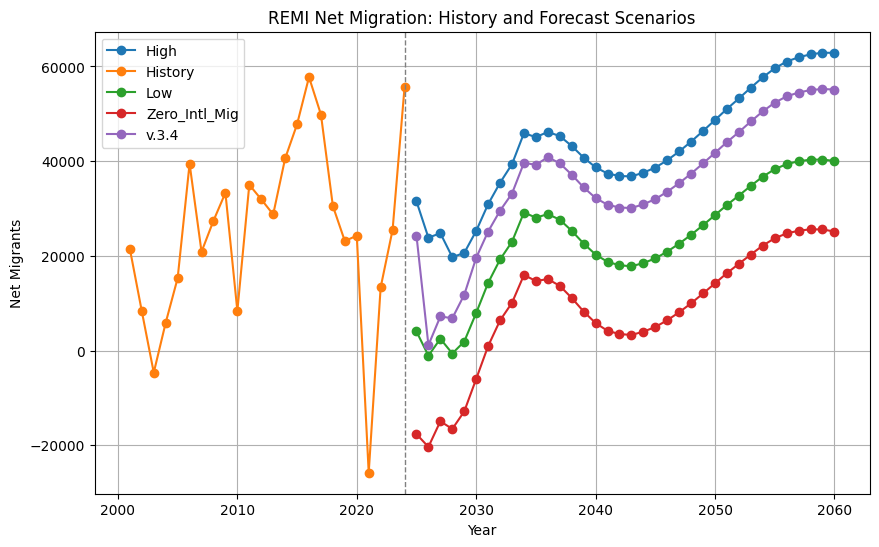

In [15]:
plt.figure(figsize=(10, 6))
for name, group in mig_all.groupby('name'):
    plt.plot(group['year'], group['net_migrants'], marker='o', label=name)
plt.axvline(remi_base_year, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Net Migrants')
plt.title('REMI Net Migration: History and Forecast Scenarios')
plt.legend()
plt.grid()
plt.show()


In [24]:
periods = [
    ("2000s", 2001, 2009),
    ("2010s", 2010, 2019),
    ("2020s", 2020, 2024),
    ("2025-2039", 2025, 2039),
    ("2040-2060", 2040, 2060),
]

period_avgs = []
for label, start, end in periods:
    subset = mig_all.loc[(mig_all['year'] >= start) & (mig_all['year'] <= end)]
    avg = subset.groupby('name')['net_migrants'].mean().rename(label)
    period_avgs.append(avg)

migration_period_avg = pd.concat(period_avgs, axis=1).T.round(0)
migration_period_avg[['History','Zero_Intl_Mig','Low','v.3.4','High']].style.format("{:,.0f}", na_rep="")


name,History,Zero_Intl_Mig,Low,v.3.4,High
2000s,"18,582",,,,
2010s,"35,358",,,,
2020s,"18,560",,,,
2025-2039,,511,"15,506","25,960","34,518"
2040-2060,,"14,452","29,000","42,314","49,318"
